# Libaries

In [1329]:
# Model
import tensorflow as tf
from tensorflow.keras import Input,regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Pre-Processing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from sklearn.decomposition import PCA

# Utilities
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Config

In [1330]:
_is_verbose = True

select_feature_k = 7
pca_k = 5

lig_regul = regularizers.l1(0.0001)
med_regul = regularizers.l2(0.001)
hev_regul = regularizers.l2(0.01)

total_samples = 3000 # Don't Change This
weight_constant = total_samples * 1
early_stopping_acc = 0.85

model_architectures = [
    Dense(128, activation='relu', kernel_regularizer=lig_regul),
    Dropout((0.3)),
    Dense(64, activation='relu', kernel_regularizer=None),
    Dropout((0.2)),
    Dense(32, activation='relu', kernel_regularizer=None),
    Dropout((0.1)),
    Dense(1, activation='sigmoid', kernel_regularizer=None)
]


# Load Data

In [1331]:
def load_data_from_csv(address: str):
    try:
        data = pd.read_csv(address)
        if(_is_verbose): print(f"CSV Data shape: {data.shape}\n")
        return data

    except Exception as e:
        raise Exception(f"Error loading CSV file on {address} : {e}")

In [1332]:
data = load_data_from_csv("Churn_Modelling.csv")

data.head()

CSV Data shape: (10000, 14)



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Pre-Processing

In [1333]:
# Removing unnecessary columns
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

print(f"CSV Data shape (after drop): {data.shape}\n")
data.head()

CSV Data shape (after drop): (10000, 11)



,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Splitting into Features and Target

In [1334]:
def get_features_and_target(data: pd.DataFrame, target_column: int):
    features = data.iloc[:, :target_column]
    target = data.iloc[:, target_column]

    if _is_verbose:
        print(f"Features shape: {features.shape}")
        print(f"Target shape: {target.shape}")
        print("————————————————————————————————————————")

    return features, target

In [1335]:
x,y = get_features_and_target(data, -1)

Features shape: (10000, 10)
Target shape: (10000,)
————————————————————————————————————————


## Label Encodding

In [1336]:
# Labeling Every Categorical Data
def encode_data(data: pd.DataFrame, keys: list):
    encoders = {}

    for key in keys:
        encoder = LabelEncoder()
        data[key] = encoder.fit_transform(data[key])
        encoders[key] = encoder

    return data, encoders

In [1337]:
x,encoders = encode_data(x,["Gender","Geography"])

x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


## Normalize Data

In [1338]:
def _standard_scaler(train_set: pd.DataFrame,test_set: pd.DataFrame):
    scaler = StandardScaler()
    train_set = scaler.fit_transform(train_set)
    test_set = scaler.transform(test_set)
    return train_set, test_set, scaler

def _min_max_scaler(train_set: pd.DataFrame,test_set: pd.DataFrame):
    scaler = MinMaxScaler()
    train_set = scaler.fit_transform(train_set)
    test_set = scaler.transform(test_set)
    return train_set, test_set, scaler



def normalize_data(train_set: pd.DataFrame,test_set: pd.DataFrame, scaler: str):
    match (scaler):
        case "StandardScaler":
            return _standard_scaler(train_set,test_set)
        case "MinMaxScaler":
            return _min_max_scaler(train_set,test_set)

def normalize_and_split_data(x,y,ratio,scaler: str):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)
    x_train, x_test, scaler = normalize_data(x_train, x_test, scaler)
    return np.array(x_train), np.array(x_test), np.array(y_train), np.array(y_test), scaler

In [1339]:
x_train, x_test, y_train, y_test, scaler = normalize_and_split_data(x,y,0.3,"StandardScaler")

print(f"X_train:\n {x_train}")
print(f"X_test:\n {x_test}")
print(f"Y_train:\n {y_train}")
print(f"Y_test:\n {y_test}")

X_train:
 [[ 1.07603413 -0.8971093  -1.08690612 ... -1.54750198  0.97210324
   1.55497172]
 [ 1.34439683 -0.8971093   0.92004266 ...  0.64620273  0.97210324
   0.1531776 ]
 [ 0.39480576  0.3182507   0.92004266 ...  0.64620273 -1.02869732
   1.21615477]
 ...
 [-0.94700771 -0.8971093   0.92004266 ...  0.64620273 -1.02869732
   0.36617835]
 [ 0.012905   -0.8971093  -1.08690612 ... -1.54750198  0.97210324
   1.70896845]
 [-0.76121815  1.5336107  -1.08690612 ...  0.64620273 -1.02869732
  -0.72263483]]
X_test:
 [[-0.09031142 -0.8971093   0.92004266 ... -1.54750198 -1.02869732
  -0.65298806]
 [-0.78186144  1.5336107  -1.08690612 ... -1.54750198 -1.02869732
  -1.20750547]
 [-0.88507786  0.3182507  -1.08690612 ... -1.54750198  0.97210324
   0.33484512]
 ...
 [-0.98829428  0.3182507  -1.08690612 ... -1.54750198  0.97210324
  -1.58462326]
 [ 0.46705725 -0.8971093   0.92004266 ...  0.64620273 -1.02869732
  -1.25395243]
 [-0.29674426  0.3182507  -1.08690612 ...  0.64620273  0.97210324
   1.10084992

## Feature Selection

In [1340]:
d_scaled = np.concatenate((x_train, y_train.reshape(-1, 1)), axis=1)
corr = pd.DataFrame(np.corrcoef(d_scaled, rowvar=False))

print("Correlation of Features and Target")
display(corr)

Correlation of Features and Target


,0,1,2,3,4,5,6,7,8,9,10
0,1.000000,0.009208,0.000511,-0.004724,0.010625,0.007887,0.022556,-0.000579,0.012558,-0.008241,-0.021716
1,0.009208,1.000000,0.020106,0.032239,0.000332,0.068159,0.017641,-0.000742,0.000495,-0.013559,0.035836
2,0.000511,0.020106,1.000000,-0.031966,0.017364,0.019235,-0.031366,0.002969,0.021159,0.001310,-0.118009
3,-0.004724,0.032239,-0.031966,1.000000,-0.017051,0.023709,-0.033255,-0.010428,0.091741,-0.001177,0.287272
4,0.010625,0.000332,0.017364,-0.017051,1.000000,-0.018622,0.022389,0.026588,-0.035062,0.010920,-0.020168
5,0.007887,0.068159,0.019235,0.023709,-0.018622,1.000000,-0.293459,-0.025578,-0.006277,0.020083,0.126539
6,0.022556,0.017641,-0.031366,-0.033255,0.022389,-0.293459,1.000000,0.007437,0.007069,0.007960,-0.045942
7,-0.000579,-0.000742,0.002969,-0.010428,0.026588,-0.025578,0.007437,1.000000,-0.021217,-0.002791,-0.011707
8,0.012558,0.000495,0.021159,0.091741,-0.035062,-0.006277,0.007069,-0.021217,1.000000,-0.008332,-0.148001
9,-0.008241,-0.013559,0.001310,-0.001177,0.010920,0.020083,0.007960,-0.002791,-0.008332,1.000000,0.013275


Since the data are mostly uncorrelated, means correlation based feature selection are not useful.

In [1341]:
def feature_selection(x_train,y_train,x_test,k):
    selector = SelectKBest(score_func=f_regression, k=5)
    x_train_new = selector.fit_transform(x_train, y_train)
    x_test_new = selector.transform(x_test)
    selected_columns = selector.get_support(indices=True)
    return x_train_new, x_test_new, selected_columns

In [1342]:
x_train_new, x_test_new, selected_columns = feature_selection(x_train,y_train,x_test,select_feature_k)

print(f"New training set shape: {x_train_new.shape}")
print(f"New testing set shape: {x_test_new.shape}")
print("Selected features:", list(data.columns[selected_columns]))

New training set shape: (7000, 5)
New testing set shape: (3000, 5)
Selected features: ['Gender', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember']


## Dimensionality Reduction

In [1343]:
def dimensionality_reduction(train,test,k):
    pca = PCA(n_components=k)
    train_pca = pca.fit_transform(train)
    test_pca = pca.transform(test)
    explained_variance = pca.explained_variance_ratio_
    return train_pca, test_pca, explained_variance

In [1344]:
xtrain_pca, xtest_pca, explained_variance = dimensionality_reduction(x_train_new,x_test_new,pca_k)

print(f"New training set shape: {xtrain_pca.shape}")
print(f"New testing set shape: {xtest_pca.shape}")
print(f"Explained variance: {explained_variance}")
print(f"Percentage of explained variance: {sum(explained_variance)*100}%")

New training set shape: (7000, 5)
New testing set shape: (3000, 5)
Explained variance: [0.26044315 0.21815913 0.20220176 0.17799106 0.1412049 ]
Percentage of explained variance: 100.0%


# Training Model

In [1345]:
def create_model(input_columns,model_architectures):
    model = Sequential()
    model.add(Input(shape=(input_columns,)))
    for layer_config in model_architectures:
            model.add(layer_config)
    return model

In [1346]:
model = create_model(xtrain_pca.shape[1],model_architectures)

model.summary()

Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_219 (Dense)               │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_220 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_221 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_222 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

In [1347]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [1348]:
class EarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, target_val_acc=0.80):
        super().__init__()
        self.target_val_acc = target_val_acc

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get("val_accuracy")
        train_acc = logs.get("accuracy")

        if val_acc is not None and val_acc >= self.target_val_acc:
            print(f"\n--- EARLY STOPPING TRIGGERED ---")
            print(f"Epoch {epoch + 1} Training Accuracy: {train_acc:.4f}")
            print(f"Epoch {epoch + 1} Validation Accuracy: {val_acc:.4f}")
            print(f"Validation accuracy reached target of {self.target_val_acc}. Stopping.")
            self.model.stop_training = True

In [1349]:
# Add "Punishment"
wa = (1 / 2377) * weight_constant
wb = (1 / 623) * weight_constant
class_weight = {0: wa, 1: wb}

print(f"Weight for class 0: {wa:.2f}")
print(f"Weight for class 1: {wb:.2f}")

Weight for class 0: 1.26
Weight for class 1: 4.82


In [1350]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.0001
)

In [1351]:
early_stopping = EarlyStopping(target_val_acc=early_stopping_acc)

history = model.fit(
    xtrain_pca,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[reduce_lr,early_stopping],
    class_weight=class_weight
)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6796 - loss: 1.1651 - val_accuracy: 0.7793 - val_loss: 0.4696 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7487 - loss: 1.0426 - val_accuracy: 0.7907 - val_loss: 0.4522 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7741 - loss: 0.9980 - val_accuracy: 0.7979 - val_loss: 0.4464 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7711 - loss: 0.9922 - val_accuracy: 0.7900 - val_loss: 0.4572 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7802 - loss: 0.9877 - val_accuracy: 0.7857 - val_loss: 0.4722 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7789 - loss: 0.9694 - val_accuracy: 0.7936 - val_loss: 0.4559 - learning_rate: 0.0010
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7786 - loss: 0.9653 

In [1352]:
model.summary()

Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_219 (Dense)               │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_220 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_221 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_222 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,413 (130.52 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,276 (87.02 KB)

In [1353]:
def plot_history(history):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history['accuracy'])
    plt.plot(history['val_accuracy'])
    plt.ylabel("Accuracy")
    plt.xlabel("Epoch")
    plt.legend(['Train','Validation'],loc="upper left")
    plt.title("Model Accuracy")

    plt.subplot(1,2,2)
    plt.plot(history['loss'])
    plt.plot(history['val_loss'])
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.legend(['Train','Validation'],loc="upper left")
    plt.title("Model Loss")

    plt.show()


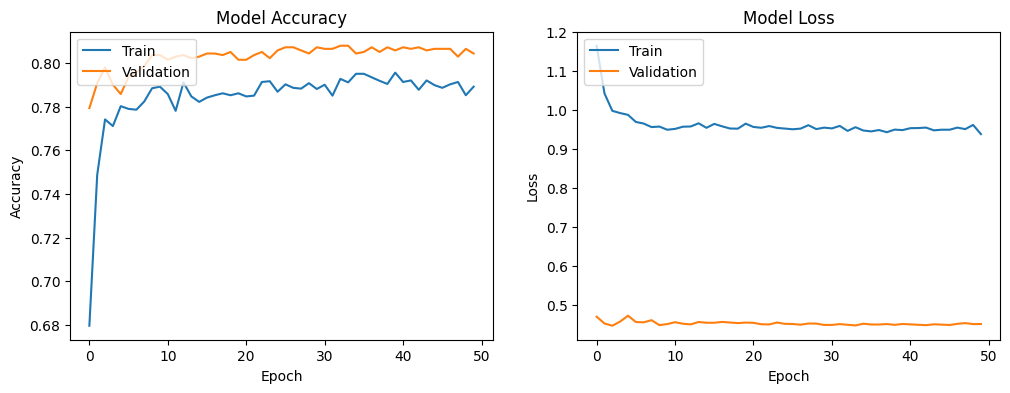

In [1354]:
plot_history(history.history)

# Evaluate Model

In [1355]:
loss, accuracy = model.evaluate(xtest_pca, y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8037 - loss: 0.4593
Test Loss: 0.45930638909339905
Test Accuracy: 0.8036666512489319


In [1356]:
targets_probability = model.predict(xtest_pca)
targets_prediction = targets_probability > 0.5

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


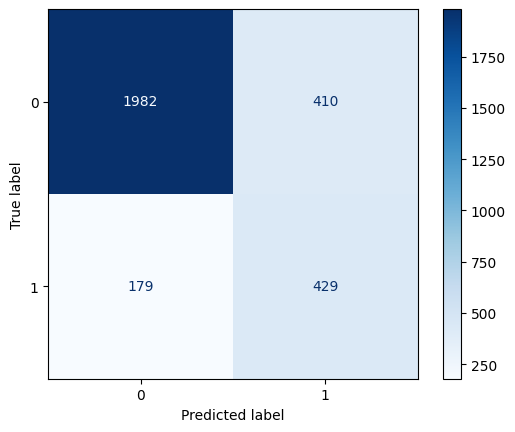

In [1357]:
cm = confusion_matrix(y_test, targets_prediction)
cm_display = ConfusionMatrixDisplay(cm)
cm_display.plot(cmap="Blues")

In [1358]:
print(classification_report(y_test, targets_prediction))

              precision    recall  f1-score   support

           0       0.92      0.83      0.87      2392
           1       0.51      0.71      0.59       608

    accuracy                           0.80      3000
   macro avg       0.71      0.77      0.73      3000
weighted avg       0.83      0.80      0.81      3000

